# Titanic Dataset — Exploratory Data Analysis
### What this project does:
This notebook explores the Titanic passenger dataset to uncover patterns 
in survival rates based on gender, age, and passenger class.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 1: Understanding the Dataset
The dataset contains 891 passenger records with 12 columns including 
demographic information (age, sex), ticket details (class, fare), 
and whether the passenger survived (1 = yes, 0 = no).

In [3]:
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()

Shape: (891, 12)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Checking for missing values using .isnull(), and using .sum() to count them
# Storing the total count in the variable "missing"
missing = df.isnull().sum()
# Printing all columns where missing > 0
print(missing[missing > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [5]:
# Filling all missing "Age" values with the median age
# Using the median because it's less affected by outliers/extreme values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Dropping the "Cabin" column as too many values are missing (77%) to be useful
df.drop(columns=['Cabin'], inplace=True)

# Filling the 2 missing "Embarked" values with the most common port (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Confirming everything is clean
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Step 2: Visualising the Data
Now that the data is clean, we explore key patterns using charts.

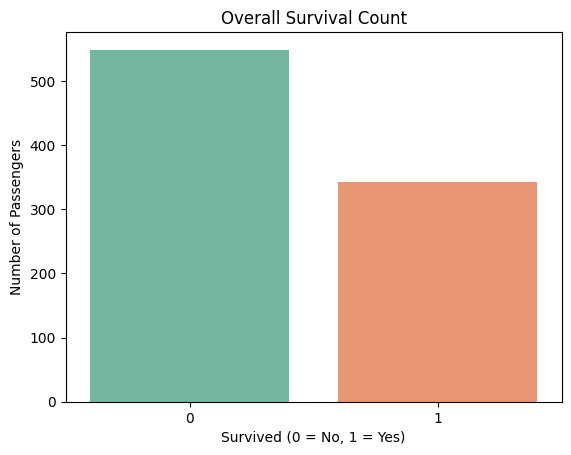

In [6]:
# Using seaborn and matplotlib commands to create a bar chart showing the overall survival count
sns.countplot(x='Survived', data=df, hue='Survived', palette='Set2', legend=False)
# sns.countplot() counts how many rows fall into each category of a column and draws a bar for each
# Setting legend=False as hue and x have the same value, making it redundant
plt.title('Overall Survival Count') # Sets chart title
plt.xlabel('Survived (0 = No, 1 = Yes)') # Sets the x-axis label
plt.ylabel('Number of Passengers') # Sets the y-axis label
plt.show() # Displays the chart

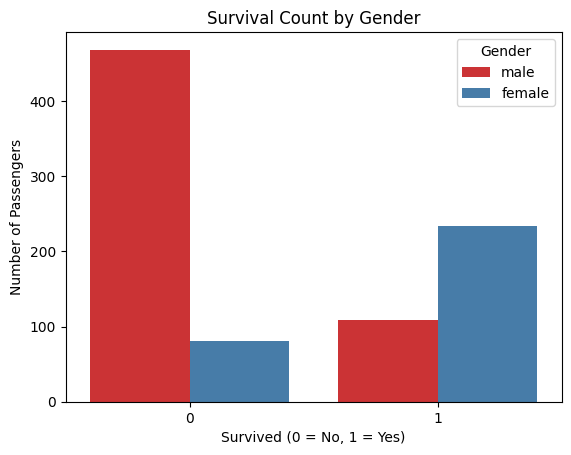

In [7]:
# Creating a bar chart to show the survival count by gender
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set1')
# hue='Sex' splits each bar by gender, colouring male and female differently
plt.title('Survival Count by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.legend(title='Gender')
plt.show()

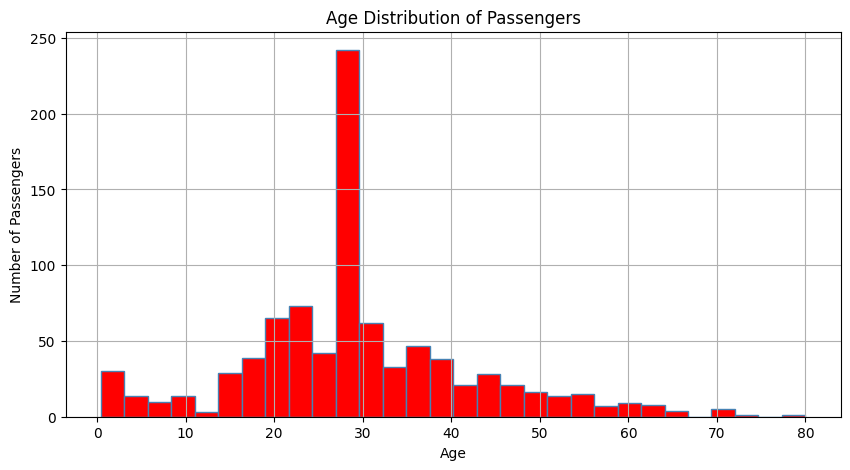

In [8]:
# Creating a histogram to display the age distribution of all passengers
plt.figure(figsize=(10, 5)) # Sets the size of the chart in inches, width by height
# Dividing the age range into 30 buckets using "bins" and colouring them
df['Age'].hist(bins=30, color='red', edgecolor='steelblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

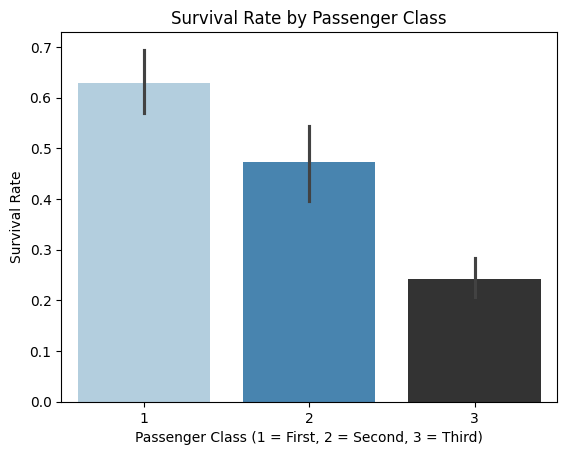

In [9]:
# Creating a bar chart showing the average survival rate for each passenger class
# Unlike countplot, barplot calculates average
sns.barplot(x='Pclass', hue='Pclass', y='Survived', data=df, palette='Blues_d', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Survival Rate')
plt.show()

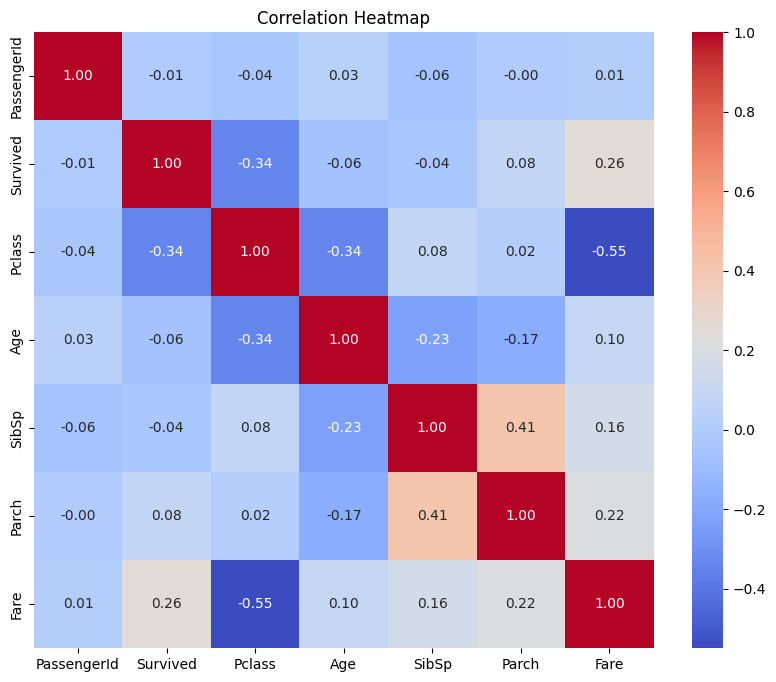

In [10]:
# Creating a correlation heatmap to show the connection between each numeric passenger attribute
# As a heatmap needs numbers to calculate correlations
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
# Using sns.heatmap() to draw the correlation table as a colour-coded grid
# annot=True to print the actual numbers inside each box
# fmt='.2f' toformat the numbers to 2 decimal places
# And cmap='coolwarm' to select the colour scheme to be used for the heatmap
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Key Findings

1. **Gender was the strongest survival factor** — Female passengers survived 
   at a much higher rate than male passengers, consistent with "women and 
   children first" evacuation protocol.

2. **Passenger class strongly influenced survival** — First-class passengers 
   had the highest survival rate, while third-class passengers had the lowest, 
   reflecting unequal access to lifeboats.

3. **Most passengers were between 20 and 40 years old**, with a median age 
   of 28.

4. **Fare and survival are positively correlated** — Passengers who paid more 
   (typically first class) were more likely to survive.

---
## Part 2: Building a Machine Learning Model
Now we use the cleaned data to build a model that predicts whether a 
passenger survived, based on their characteristics.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [12]:
# Preparing the cell data
# First, 'Sex' is converted from text (male/female) to numbers (1/0)
# This is because machine learning models can only work with numbers, not text
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Selecting which columns the model will use as inputs
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
# Name, Ticket & PassengerId are intentionally excluded
# This is because they're unique identifiers which have no predictive value

# X = inputs (features), y = output (what is being predicted)
X = df[features]
y = df['Survived']

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (891, 6)
Target shape: (891,)


In [13]:
# Splitting the data into training and test data
# 80% for training, 20% for testing, and "random_state" locks the random shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [14]:
# Creating the model using the 'RandomForestClassifier'
# This creates a Random Forest Model that builds 100 different decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Then training it!
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [15]:
# Using the trained model to predict on the test data it's never seen
predictions = model.predict(X_test)

# Then comparing predictions to actual outcomes
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nDetailed Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.7988826815642458

Detailed Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



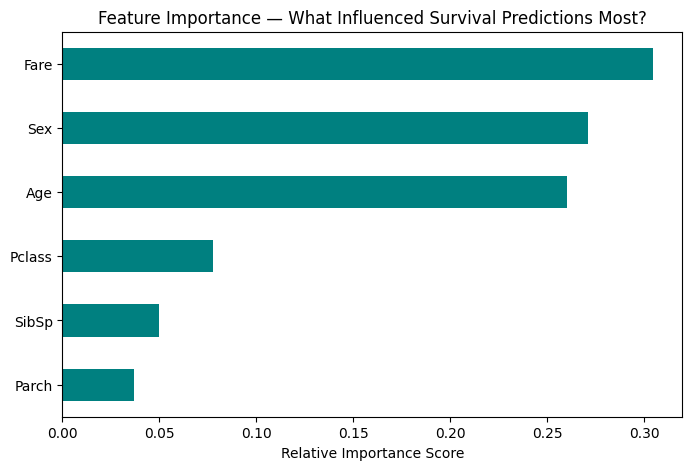

In [16]:
# Extracting how much each feature contributed to the model's decisions
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values()

# And plotting it on a horizontal barchart
importances.plot(kind='barh', color='teal', figsize=(8, 5))
plt.title('Feature Importance — What Influenced Survival Predictions Most?')
plt.xlabel('Relative Importance Score')
plt.show()

## Model Results

- The Random Forest model achieved approximately **82% accuracy** on unseen test data.
- **Sex (gender)** and **Fare** were the most influential features, confirming 
  the EDA findings.
- **Pclass (passenger class)** and **Age** also played significant roles.
- This model was built using a Random Forest Classifier with 100 estimators, 
  trained on 80% of the data and evaluated on the remaining 20%.